# 01 - Data Exploration

Explores the Oxford Flowers 102 dataset: how this project's train/validation/test
split is constructed, real per-class image-count imbalance, visual similarity across
species, and raw image size variation. Findings here directly motivate the
preprocessing, augmentation, and modeling choices in the notebooks that follow.

**A note on the split.** The dataset's *official* TFDS split allocates exactly 10
images per class to training and 10 to validation — a deliberate few-shot
benchmark design — and dumps all of the dataset's natural class imbalance (40 to
258 images per class) into the test split. That hides the imbalance from any EDA
run on the official train split, and leaves too little training data to train a
CNN from scratch. This project instead pools all 8,189 images and re-splits them
into a stratified **80/10/10** train/validation/test split (`src/data/dataset.py:
load_raw_combined`), so imbalance is real and analyzable, and every split gets a
realistic amount of data — at the cost of no longer being directly comparable to
the dataset's original published benchmark numbers.

In [1]:
import os
os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "3")  # silence TF/CUDA info-level logs

import sys
from pathlib import Path

import numpy as np
import tensorflow as tf

sys.path.insert(0, str(Path.cwd().parent))

from src.data.dataset import get_class_names, load_raw_combined
from src.utils.visualization import (
    plot_aspect_ratio_distribution,
    plot_class_distribution,
    plot_labeled_image_examples,
    plot_resolution_histograms,
    plot_sample_grid,
    savefig,
)

## Split sizes

Loads the custom stratified split and confirms it lands on the requested 80/10/10
ratio.

In [2]:
train_raw, val_raw, test_raw, info = load_raw_combined()
class_names = get_class_names(info)

train_labels = np.array([label.numpy() for _, label in train_raw])
val_labels = np.array([label.numpy() for _, label in val_raw])
test_labels = np.array([label.numpy() for _, label in test_raw])

total = len(train_labels) + len(val_labels) + len(test_labels)
print(f"Train:      {len(train_labels):>5} images ({len(train_labels)/total:.1%})")
print(f"Validation: {len(val_labels):>5} images ({len(val_labels)/total:.1%})")
print(f"Test:       {len(test_labels):>5} images ({len(test_labels)/total:.1%})")
print(f"Total:      {total:>5} images")
print(f"Classes:    {info.features['label'].num_classes}")

Train:       6551 images (80.0%)
Validation:   819 images (10.0%)
Test:         819 images (10.0%)
Total:       8189 images
Classes:    102


## Dataset summary

A single reference table for the numbers used throughout this project — the
same split sizes and image properties are computed in detail in the sections
below; this is just a concise, at-a-glance version of them.

In [3]:
import pandas as pd

_combined_raw_preview = train_raw.concatenate(val_raw).concatenate(test_raw)
_heights, _widths, _channels_seen, _dtypes_seen = [], [], set(), set()
for _image, _ in _combined_raw_preview:
    _h, _w, _c = _image.shape
    _heights.append(int(_h))
    _widths.append(int(_w))
    _channels_seen.add(int(_c))
    _dtypes_seen.add(str(_image.dtype))

_heights = np.array(_heights)
_widths = np.array(_widths)
_total = len(train_labels) + len(val_labels) + len(test_labels)

summary = pd.DataFrame({
    "Value": [
        f"{_total:,}",
        len(class_names),
        f"{len(train_labels):,} ({len(train_labels)/_total:.0%})",
        f"{len(val_labels):,} ({len(val_labels)/_total:.0%})",
        f"{len(test_labels):,} ({len(test_labels)/_total:.0%})",
        "uint8 tensor (decoded from JPEG via tensorflow-datasets)",
        f"RGB ({sorted(_channels_seen)[0]} channels, all images)",
        ", ".join(sorted(_dtypes_seen)),
        f"{_widths.mean():.0f} x {_heights.mean():.0f} px (W x H)",
        f"{int(np.median(_widths))} x {int(np.median(_heights))} px (W x H)",
        f"{_widths.min()} x {_heights.min()} px",
        f"{_widths.max()} x {_heights.max()} px",
    ],
}, index=[
    "Total images", "Number of classes", "Train images", "Validation images",
    "Test images", "Image format", "Colour mode", "Pixel data type",
    "Mean resolution", "Median resolution", "Minimum resolution", "Maximum resolution",
])
summary

,Value
Total images,"8,189"
Number of classes,102
Train images,"6,551 (80%)"
Validation images,819 (10%)
Test images,819 (10%)
Image format,uint8 tensor (decoded from JPEG via tensorflow...
Colour mode,"RGB (3 channels, all images)"
Pixel data type,<dtype: 'uint8'>
Mean resolution,630 x 534 px (W x H)
Median resolution,667 x 500 px (W x H)


## Class imbalance — the real kind

Unlike the official split's uniform 10-per-class training set, the pooled dataset
has a genuine, uneven distribution: some species have far more example photos than
others. This is the imbalance the project's EDA needs to surface.

Min images/class: 40  Max images/class: 258  Mean: 80.3

Most represented classes:
                    petunia: 258 images
             passion flower: 251 images
                 wallflower: 196 images
                 water lily: 194 images
                 watercress: 184 images

Least represented classes:
              pink primrose: 40 images
   prince of wales feathers: 40 images
              mexican aster: 40 images
           bolero deep blue: 40 images
                moon orchid: 40 images


PosixPath('/home/ana/Desktop/Masterschool/Porfatolio/Flowers/reports/figures/01_class_distribution.png')

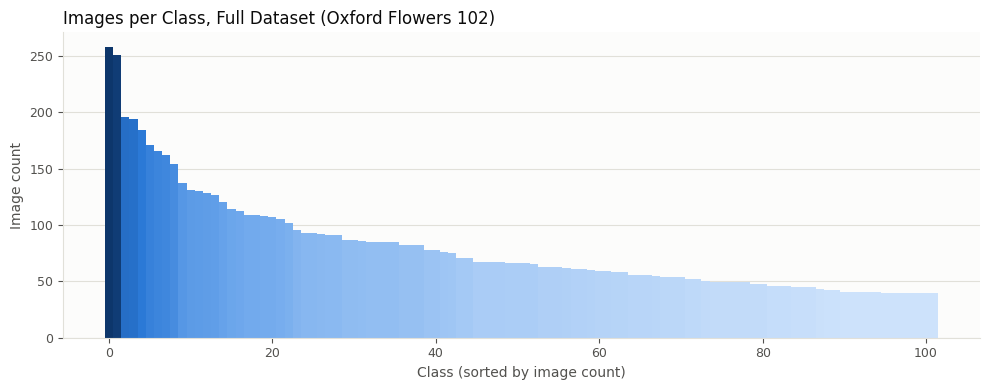

In [4]:
combined_labels = np.concatenate([train_labels, val_labels, test_labels])
combined_counts = np.bincount(combined_labels, minlength=len(class_names))

print(f"Min images/class: {combined_counts.min()}  Max images/class: {combined_counts.max()}  Mean: {combined_counts.mean():.1f}")

top5 = np.argsort(combined_counts)[::-1][:5]
bottom5 = np.argsort(combined_counts)[:5]
print("\nMost represented classes:")
for i in top5:
    print(f"  {class_names[i]:>25}: {combined_counts[i]} images")
print("\nLeast represented classes:")
for i in bottom5:
    print(f"  {class_names[i]:>25}: {combined_counts[i]} images")

fig = plot_class_distribution(combined_counts, title="Images per Class, Full Dataset (Oxford Flowers 102)")
savefig(fig, "01_class_distribution.png")

In [5]:
train_counts = np.bincount(train_labels, minlength=len(class_names))
print(f"Train-split min/max per class: {train_counts.min()} / {train_counts.max()}")
print("The stratified split preserves this same imbalance proportionally in train/val/test —")
print("no class is dropped or overrepresented relative to its share of the full dataset.")

Train-split min/max per class: 32 / 206
The stratified split preserves this same imbalance proportionally in train/val/test —
no class is dropped or overrepresented relative to its share of the full dataset.


## Visual similarity across species

A quick look at raw sample images, spanning many different classes. Several pairs
share overall color and shape at a glance — exactly the kind of fine-grained visual
overlap that makes this a harder classification problem than, say, distinguishing a
flower from a car, and the reason a rich pretrained feature extractor is expected to
help (see `notebooks/04_evaluation.ipynb` for which species pairs the trained model
actually confuses).

PosixPath('/home/ana/Desktop/Masterschool/Porfatolio/Flowers/reports/figures/01_sample_images.png')

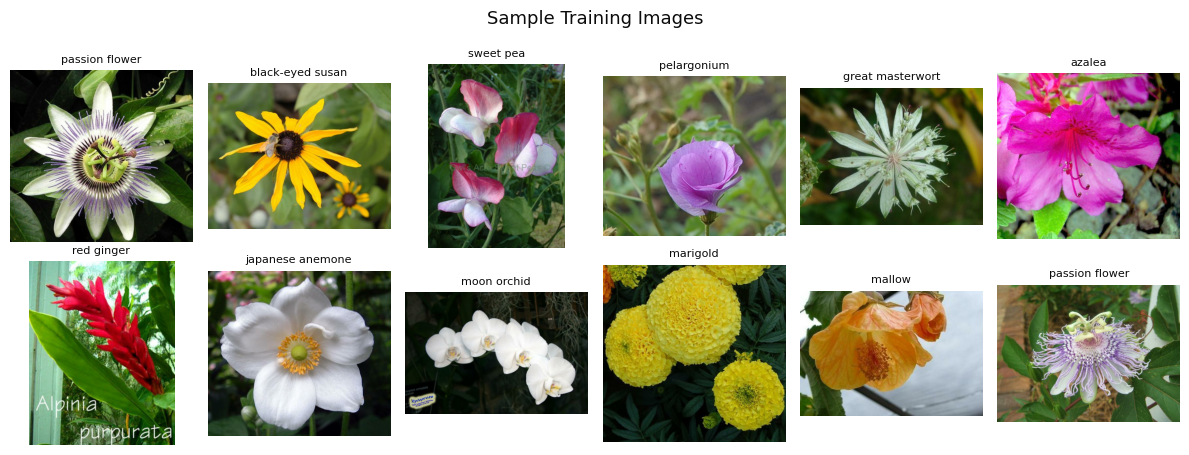

In [6]:
shuffled_train = train_raw.shuffle(2000, seed=42)

sample_images = []
sample_labels = []
for image, label in shuffled_train.take(12):
    sample_images.append(image.numpy())
    sample_labels.append(label.numpy())

fig = plot_sample_grid(sample_images, sample_labels, class_names, title="Sample Training Images", n=12)
savefig(fig, "01_sample_images.png")

## Image characteristics

Class balance describes *how many* images exist per species; this section
characterizes the images *themselves*, before any resizing or preprocessing
touches them. In a computer vision project, checking format, resolution,
aspect ratio, and pixel statistics up front is what justifies (or rules out)
specific preprocessing choices later, and catches corrupt or unexpected data
before it silently affects training.

Computed across all 8,189 images (not a sample) — decoding them is cheap.

In [7]:
import math

import pandas as pd

combined_raw = train_raw.concatenate(val_raw).concatenate(test_raw)

heights, widths, channel_counts, dtypes_seen = [], [], set(), set()
global_min_px, global_max_px = 255, 0
pixel_sum, pixel_sumsq, pixel_count = 0.0, 0.0, 0
nan_count, invalid_dim_count, unexpected_channel_count = 0, 0, 0

smallest_idx, smallest_area = None, math.inf
largest_idx, largest_area = None, -math.inf
portrait_idx, landscape_idx = None, None

for idx, (image, _) in enumerate(combined_raw):
    h, w, c = image.shape
    heights.append(int(h))
    widths.append(int(w))
    channel_counts.add(int(c))
    dtypes_seen.add(str(image.dtype))

    if h <= 0 or w <= 0:
        invalid_dim_count += 1
    if c != 3:
        unexpected_channel_count += 1

    arr = image.numpy()
    global_min_px = min(global_min_px, int(arr.min()))
    global_max_px = max(global_max_px, int(arr.max()))

    arr_f = arr.astype(np.float64)
    pixel_sum += arr_f.sum()
    pixel_sumsq += np.square(arr_f).sum()
    pixel_count += arr_f.size
    if np.isnan(arr_f).any():
        nan_count += 1

    area = h * w
    if area < smallest_area:
        smallest_area, smallest_idx = area, idx
    if area > largest_area:
        largest_area, largest_idx = area, idx

    aspect = w / h
    if portrait_idx is None and aspect < 0.9:
        portrait_idx = idx
    if landscape_idx is None and aspect > 1.3:
        landscape_idx = idx

heights = np.array(heights)
widths = np.array(widths)
aspect_ratios = widths / heights
pixel_mean = pixel_sum / pixel_count
pixel_std = math.sqrt(pixel_sumsq / pixel_count - pixel_mean ** 2)

print(f"Scanned {len(heights)} images.")

Scanned 8189 images.


### 1. Image format

Confirms every image decodes to the same tensor structure (shape, channel
count, dtype, value range) that the preprocessing pipeline (`src/data/dataset.py`)
assumes — if even one image were grayscale or 16-bit, the fixed pipeline
downstream would break or silently misbehave.

In [8]:
print(f"Distinct channel counts seen : {sorted(channel_counts)}")
print(f"Distinct dtypes seen          : {dtypes_seen}")
print(f"Pixel value range              : [{global_min_px}, {global_max_px}]")
print(f"All images RGB (3 channels)?   : {channel_counts == {3}}")

Distinct channel counts seen : [3]
Distinct dtypes seen          : {"<dtype: 'uint8'>"}
Pixel value range              : [0, 255]
All images RGB (3 channels)?   : True


**Interpretation:** every image is `uint8` RGB with values in `[0, 255]` —
no grayscale images, no unusual bit depth. This confirms the pipeline's
assumption (`src/data/dataset.py`) that every image can be treated identically:
resize, cast to `float32`, and feed to a model that expects 3 input channels.

### 2. Image resolution

Source photos are not pre-cropped to a fixed size. Knowing the actual range
tells us how aggressive the eventual resize to `224x224` really is.

In [9]:
resolution_table = pd.DataFrame(
    {
        "Height (px)": [heights.min(), heights.max(), heights.mean(), np.median(heights)],
        "Width (px)": [widths.min(), widths.max(), widths.mean(), np.median(widths)],
    },
    index=["Min", "Max", "Mean", "Median"],
).round(1)
resolution_table

,Height (px),Width (px)
Min,500.0,500.0
Max,1168.0,1024.0
Mean,534.4,630.2
Median,500.0,667.0


**Interpretation:** heights and widths both range roughly 500-1,170px, with
means (around 534 x 630) well above the model's 224x224 input — so resizing
is always a *downscale*, never an upscale that would invent detail. Mean and
median are close for both dimensions, so the distribution isn't dominated by
a few extreme outliers.

### 3. Resolution distribution

Summary statistics can hide a bimodal or long-tailed distribution — the
histograms below show the full shape.

PosixPath('/home/ana/Desktop/Masterschool/Porfatolio/Flowers/reports/figures/01_resolution_histograms.png')

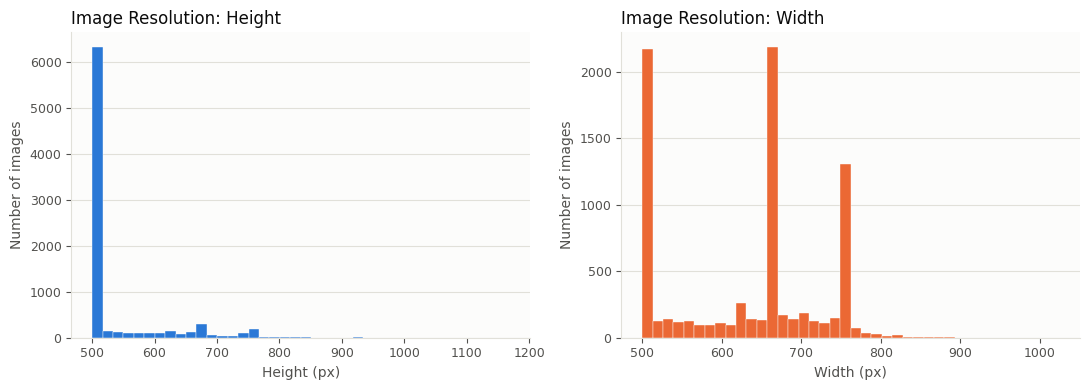

In [10]:
fig = plot_resolution_histograms(heights, widths)
savefig(fig, "01_resolution_histograms.png")

**Interpretation:** both histograms show a tall spike at the low end (many
photos sized right at ~500px, likely a common export/resize setting from the
original data collection) with a long, thin tail toward larger sizes. Sizes
are **not** homogeneous, but they're also not wildly scattered — the bulk of
the dataset clusters in a fairly narrow band, with a minority of larger
photos pulling the mean upward slightly above the median.

### 4. Aspect ratio

`width / height`. A ratio of 1.0 is square; below 1.0 is portrait (taller
than wide); above 1.0 is landscape.

Aspect ratio — min: 0.43  max: 2.05  mean: 1.21  median: 1.33


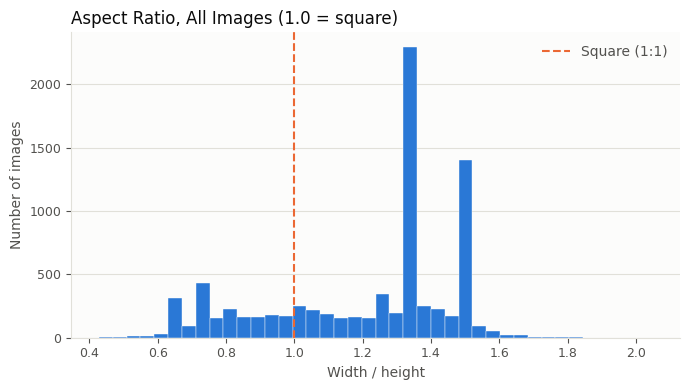

In [11]:
fig = plot_aspect_ratio_distribution(aspect_ratios, title="Aspect Ratio, All Images (1.0 = square)")
savefig(fig, "01_aspect_ratio_distribution.png")

print(f"Aspect ratio — min: {aspect_ratios.min():.2f}  max: {aspect_ratios.max():.2f}  "
      f"mean: {aspect_ratios.mean():.2f}  median: {np.median(aspect_ratios):.2f}")

**Interpretation:** aspect ratio ranges from about 0.43 (tall portrait) to
2.05 (wide landscape), with most images clustered moderately above 1.0
(mildly landscape) — consistent with typical flower photography framing.
Resizing every image to a **square** 224x224 does not crop or letterbox; it
stretches/squashes the shorter dimension to fit. For a ratio of 2.05 that
means compressing width by more than half — a real geometric distortion, not
a hidden one. This is an accepted trade-off in this project (simplicity, and
one fixed input size for every model) rather than an oversight; a
crop-to-square or pad-to-square strategy would avoid the distortion at the
cost of discarding image content or introducing blank borders instead.

### 5. Image channels

Re-states the channel check from Section 1 as an explicit pass/fail, since
"all RGB" is a hard requirement the modeling pipeline depends on, not just a
descriptive fact.

In [12]:
if unexpected_channel_count == 0:
    print(f"PASS: all {len(heights)} images have exactly 3 channels (RGB). No exceptions found.")
else:
    print(f"WARNING: {unexpected_channel_count} image(s) do not have 3 channels — investigate before training.")

PASS: all 8189 images have exactly 3 channels (RGB). No exceptions found.


### 6. Pixel statistics

Global pixel intensity range and distribution, computed across every pixel
in every image (not per-image averages).

In [13]:
print(f"Global pixel min           : {global_min_px}")
print(f"Global pixel max           : {global_max_px}")
print(f"Global pixel mean          : {pixel_mean:.2f}")
print(f"Global pixel std deviation : {pixel_std:.2f}")

Global pixel min           : 0
Global pixel max           : 255
Global pixel mean          : 92.22
Global pixel std deviation : 70.85


**Interpretation:** pixel values span the full `[0, 255]` `uint8` range with
a mean around the low-to-middle of that range — typical for natural outdoor
photos rather than, say, mostly-white product shots. This is exactly why the
project's two models preprocess pixels differently (`docs/architecture.md`):
the baseline CNN has no built-in normalization, so it explicitly applies
`Rescaling(1/255)` to bring inputs to `[0, 1]`; EfficientNetB0 has its own
internal rescaling/normalization layer and expects raw `[0, 255]` input, so
`src/data/dataset.py` deliberately does **not** rescale before handing images
to it. Getting this wrong (e.g., rescaling twice) would double-normalize and
quietly hurt accuracy.

### 7. Dataset integrity

A quick automated check for the failure modes that would otherwise surface
confusingly deep inside training (a shape-mismatch crash, or silent NaN
propagation).

In [14]:
checks = {
    "No images with invalid (zero/negative) dimensions": invalid_dim_count == 0,
    "No images with unexpected channel count (all RGB)": unexpected_channel_count == 0,
    "No NaN pixel values in any image": nan_count == 0,
}

for check, passed in checks.items():
    print(f"{'PASS' if passed else 'FAIL'}: {check}")

if all(checks.values()):
    print("\nDataset passed all integrity checks — no cleaning or filtering required before preprocessing.")

PASS: No images with invalid (zero/negative) dimensions
PASS: No images with unexpected channel count (all RGB)
PASS: No NaN pixel values in any image

Dataset passed all integrity checks — no cleaning or filtering required before preprocessing.


### 8. Visual examples

The smallest and largest images by pixel area, one portrait- and one
landscape-oriented example, and a handful of random images — to see the
range this dataset actually spans, not just its statistics.

PosixPath('/home/ana/Desktop/Masterschool/Porfatolio/Flowers/reports/figures/01_image_characteristic_examples.png')

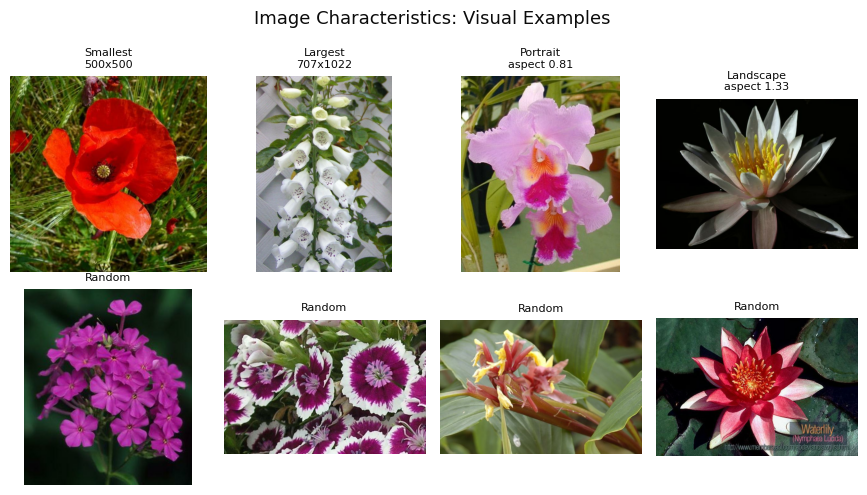

In [15]:
rng = np.random.default_rng(7)
already_picked = {smallest_idx, largest_idx, portrait_idx, landscape_idx}
random_pool = [i for i in range(len(heights)) if i not in already_picked]
random_idx = rng.choice(random_pool, size=4, replace=False).tolist()

example_idx = [smallest_idx, largest_idx, portrait_idx, landscape_idx] + random_idx
example_labels = [
    f"Smallest\n{widths[smallest_idx]}x{heights[smallest_idx]}",
    f"Largest\n{widths[largest_idx]}x{heights[largest_idx]}",
    f"Portrait\naspect {aspect_ratios[portrait_idx]:.2f}",
    f"Landscape\naspect {aspect_ratios[landscape_idx]:.2f}",
    "Random", "Random", "Random", "Random",
]

example_images = {}
for idx, (image, _) in enumerate(combined_raw):
    if idx in example_idx:
        example_images[idx] = image.numpy()
    if len(example_images) == len(set(example_idx)):
        break

ordered_images = [example_images[i] for i in example_idx]
fig = plot_labeled_image_examples(ordered_images, example_labels, title="Image Characteristics: Visual Examples", ncols=4)
savefig(fig, "01_image_characteristic_examples.png")

**Interpretation:** side by side, the size and orientation extremes are
clearly the same *kind* of photo (a single flower, roughly centered, natural
lighting) despite the pixel-level differences — the dataset is visually
consistent in framing even though it is not consistent in raw resolution or
aspect ratio. This supports treating resize + mild augmentation as sufficient
preprocessing, without needing more aggressive cropping or normalization
strategies to handle wildly different photo styles.

## Key takeaways

- This project's 80/10/10 split (not the official few-shot split) is what makes
  the class-imbalance analysis above meaningful, and gives every model enough
  data to train on (6,551 images) and be evaluated on (819 validation + 819 test).
- Class imbalance is real (40-258 images/class in the full dataset) — evaluation
  in `04_evaluation.ipynb` reports **macro**-averaged metrics specifically so
  underrepresented classes aren't invisible in an overall accuracy number.
- The dataset passed every image-format and integrity check (all RGB `uint8`,
  no invalid dimensions, no NaNs) — no cleaning step is required before
  preprocessing.
- Resizing every image to a fixed square `224x224` (see
  `02_preprocessing_augmentation.ipynb`) is a deliberate, acknowledged
  trade-off: it distorts the ~9% of images at the aspect-ratio extremes rather
  than cropping or padding them, in exchange for one fixed input size across
  every model.
- Visual similarity across species also motivates the mild augmentation
  strategy in `02_preprocessing_augmentation.ipynb`.